# Исследование анализа рынка Москвы

- Автор: Захаров Максим 
- Дата: 08.01.2025

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных рынка заведений общественного питания Москвы.

**Задачи:** 
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:\
\-изучить данные более детально;
\-изучить и найти  взаимосвязь между данными
4. Сформулировать выводы по проведенному анализу.

## Данные 

Для анализа поступили данные сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят из двух датасетов:

- `datasets/rest_info.csv` -информация о заведениях общественного питания;
- `datasets/rest_price.csv` -информацию о среднем чеке в заведениях общественного питания

### Описание датасета `datasets/rest_info.csv`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.
seats — количество посадочных мест

### Описание датасета `datasets/rest_price.csv`

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»: 
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»


### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы. 

---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загружаем данные из датасетов datasets/rest_info.csv и /datasets/rest_price.csv в датафреймы :
rest_info_df=pd.read_csv('/datasets/rest_info.csv')
rest_price_df=pd.read_csv('/datasets/rest_price.csv')



- Познакомьтесь с данными и изучите общую информацию о них.

Познакомимся с данными датасета /datasets/rest_info.csv. Выведем первые строчки методом `head()`, а информацию о датафрейме методом `info()` 

In [3]:
rest_info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
rest_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

После первичного анализа можно сделать следующие выводы:

    -названия столбцов уже приведены к одному виду snake case и не требуют изменений
    -Типы данных в основном присвоены корректно, кроме seats хранится как float64,но должно быть целым числом. Можно преобразовать в int64
    -Текстовые поля(id,name,category,address,district,hours) хранятся как object.
    -Рейтинг (rating) - float64 допускает дробные значения
    -Сетевая принадлежность(chain) - int64,тк бинарный признак 0/1
    
В данных встречаются пропуски. Критическими являются `seats`-3611(43%),умеренные:`hours`-535(6.4%).Остальные 7 столбцов заполнены полностью верно. 


    
    

Теперь познакомимся с данными датасета `/datasets/rest_price.csv`

In [5]:
rest_price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
rest_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк в которых представлена информация о среднем чеке в заведениях общественного питания

- Названия столбцов уже приведены к одному виду snake case,не требуют изменений.
- Типы данных соответствуют содержимому.Встречаются данные двух типов: 
    Текстовые поля - object (id,price,avg_bill) 
    и Числовые - float64(middle_avg_bill,middle_coffee_cup) 
- Пропуски содержатся в нескольких столбцах:
    price(18,3%), avg_bill(6,0%), middle_avg_bill(22,4%), middle_coffee_cup(88,6%).Особо критично малое заполнение данных о стоимости кофе.
    -Данные соответствуют описанию: столбец avg_bill содержит текстовые описания цен, из которых извлечены числовые значения middle_avg_bill и middle_coffee_cup.
    - В middle_coffee_cup заполнен только для записей, где в avg_bill указана цена купучино, что объясняет высокий процент пропусков в этом столбце.
    

---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Первичное знакомство показывает, что данные полностью соответствуют описанию - содержат заявленные характеристики заведений и ценовую информацию. Основные выявленные проблемы - значительные пропуски в ключевых столбцах и необходимость преобразования типов данных. Переходим к следующему этапу - предобработке данных

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [7]:
# Объединяем датасеты:
rest_info_df.merge(rest_price_df,on='id',how='inner')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4053,962800540173458486f3c465437c2d8b,Pab&burg,"бар,паб","Москва, улица Михайлова, 22, корп. 4",Юго-Восточный административный округ,"ежедневно, 12:00–21:30",4.2,0,NaN,средние,Цена бокала пива:от 140 ₽,NaN,NaN
4054,4277890d659341848d7051cbf2e51f51,Пекинский Двор,ресторан,"Москва, Ленинский проспект, 158",Западный административный округ,"ежедневно, 11:00–23:00",4.3,0,200.0,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
4055,026cbc478f9b4c3294a83458dcd89982,Траектория Крафт-Кафе,пиццерия,"Москва, улица Лобачевского, 52, корп. 1",Западный административный округ,"пн-пт 10:00–23:00; сб,вс 12:00–23:00",4.4,0,60.0,средние,NaN,NaN,NaN
4056,71cc394927204d45b81c3a91edb47955,"Пекарня, кафе-гриль",булочная,"Москва, Болотниковская улица, 52, корп. 2",Юго-Западный административный округ,"ежедневно, круглосуточно",4.2,0,50.0,NaN,Средний счёт:50–250 ₽,150.0,NaN


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [8]:
#Объединяем и преобразуем типы:
rest_df=rest_info_df.merge(rest_price_df,on='id',how='inner')
rest_df['seats']=rest_df['seats'].astype('Int64')

# Проверяем результат:
print(rest_df.dtypes)
print(rest_df.shape)

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                  int64
seats                  Int64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object
(4058, 13)


- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [9]:
# Проверяем данные на наличие пропусков в датафрейме rest_info :
rest_info_df.isna().sum()

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [10]:
# Подсчитываем процент строк с пропусками в датафрейме rest_info :
rest_info_df.isna().sum()/len(rest_info_df)*100

id           0.000000
name         0.000000
category     0.000000
address      0.000000
district     0.000000
hours        6.376398
rating       0.000000
chain        0.000000
seats       42.957411
dtype: float64

Пропуски в rest_info_df:

- hours 536 пропусков (6.38%) - информация о днях и часах работы. Возможно заведение является новым и владелец не установил режим работы либо не обновили информацию.
- seats 3611 пропусков (42.96%) - информация о количестве посадочных мест. Заведение может является булочной/пекарней формата "взять и уйти"

In [11]:
# Обрабатываем пропуски в датафрейме rest_info_df:
# hourse - заполним информация "отсутствует"
rest_info_df['hours']=rest_info_df['hours'].fillna('информация отсутствует')
# seats - 0 мест = формат с "собой" 
rest_info_df['seats']=rest_info_df['seats'].fillna(0)


In [12]:
# Проверяем данные на наличие пропусков в датафрейме rest_price :
rest_price_df.isna().sum()

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

In [13]:
# Подсчитываем процент строк с пропусками в датафрейме rest_price :
rest_price_df.isna().sum()/len(rest_price_df)*100

id                    0.000000
price                18.309512
avg_bill              5.963529
middle_avg_bill      22.400197
middle_coffee_cup    86.816166
dtype: float64

Пропуски в rest_price_df :

- price (18.3% пропусков) - категория цен в заведении. Заведение без фиксированного меню: концепции с часто меняющимися предложениями.
- avg_bill (6.0% пропусоков) - средняя стоимость заказа. У заведения может отсутствовать меню онлайн.
- middle_avg_bill(22.4% пропусков) - числовая оценка среднего чека. Заполняется только когда `avg_bill` начинается с подстроки "Средний счет".
- middle_coffee_cup(86.8% пропусков) - числовая оценка одной чашки капучино. Заполняется только когда в `avg_bill` начинается с подстроки "Цена одной чашки капучино".

    
    

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [14]:
# Проверяем полные дубликаты в датафрейме rest_info_df
rest_info_df.duplicated().sum()

0

In [15]:
# Проверяем полные дубликаты в датафрейме rest_price_df
rest_price_df.duplicated().sum()

0

В датафреймах нет полных дупликатов строк. Проверим неявные дубликаты - значения по значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальное заведение:

In [16]:
# Проверяем неявные дубликаты в датафрейме rest_info_df
rest_info_df.duplicated(subset='id').sum()

0

In [17]:
# Проверяем неявные дубликаты в датафрейме rest_info_df
rest_price_df.duplicated(subset='id').sum()

0

In [18]:
# Обрабатываем пропуски в датафрейме rest_price_df:
# Заполняем пропуски
rest_price_df['price'] = rest_price_df['price'].fillna('не указано')
rest_price_df['avg_bill'] = rest_price_df['avg_bill'].fillna('информации нет')

# Заполняем средний чек средним значением
avg_bill_mean = rest_price_df['middle_avg_bill'].mean()
rest_price_df['middle_avg_bill'] = rest_price_df['middle_avg_bill'].fillna(avg_bill_mean)

# Заполняем цену кофе нулем (если нет цены, значит не продают)
rest_price_df['middle_coffee_cup'] = rest_price_df['middle_coffee_cup'].fillna(0)

# Проверяем
print("Пропуски после обработки:")
print(rest_price_df.isna().sum())

Пропуски после обработки:
id                   0
price                0
avg_bill             0
middle_avg_bill      0
middle_coffee_cup    0
dtype: int64


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [19]:
# Создаем единый датафрейм
rest_df = rest_info_df.merge(rest_price_df, on='id', how='inner')

# Создаем новый столбец 
rest_df['is_24_7']=False

# Ищем круглосуточные заведения
mask = rest_df['hours'].str.contains('круглосуточно',na=False)
rest_df.loc[mask,'is_24_7']=True

# Проверяем 
print(f"Всего заведений: {len(rest_df)}")
print(f"Круглосуточно: {rest_df['is_24_7'].sum()}")

Всего заведений: 4058
Круглосуточно: 279


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

Данные подготовили для дальнейшнего исследовательского анализа.Объединили два датасета `rest_info.csv` и `rest_price.csv` по полю `id`. Итоговый датафрейм содержит 4058 строк и 13 столбцов.

- Столбец `seats` преобразован из `float64` в `Int64` для корректного хранения целочисленных значений с поддержкой пропусков.
- Остальные типы данных остались без изменений,поскольку соответствуют хранимой информации.
- Пропуски в `middle_coffee_cup` и  `middle_avg_bill`не являются ошибкой данных - заполнение этих полей происходит выборочно на основе содержимого avg_bill. На этом этапе пропуски не удалялись и не заполнялись,оставлены для дальнейшего анализа.
- Что было сделано с пропусками:
* `hours`: заполнили значением "информация отсутствует" -> график работы неизвестен,но заведение существует 
* `seats`: заполнили 0 "формат с собой" -> если места не указаны, считаем формат "с собой"
* `price`: заполнили "не указано" -> ценовую категорию невозможно определить автоматически
* `avg_bill`: заполнены "информации нет" -> данные о ценах отсутствуют в открытых источниках
* `middle_avg_bill`: среднее значение -> заполнили средним чеком для сохранения числового анализа
* `middle_coffee_cup`:заполнили  0 -> если цена не указана,значит кофе не продается или не является основным продуктом
- Полные дупликаты не обнаружены 
- Создан столбец `is_24_7` (279 круглосуточных заведений)




Основные проблемы качества данных и пропуски выявлены и задокументированы.Создан объединенный датафрейм с новым признаком,готовый для дальнейшего анализа и визуализации.


## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1
Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.


In [20]:
# Изучаем категории
print(rest_df['category'].value_counts().head(10))

ресторан           1103
кофейня             758
кафе                734
бар,паб             522
пиццерия            456
быстрое питание     249
столовая            182
булочная             54
Name: category, dtype: int64


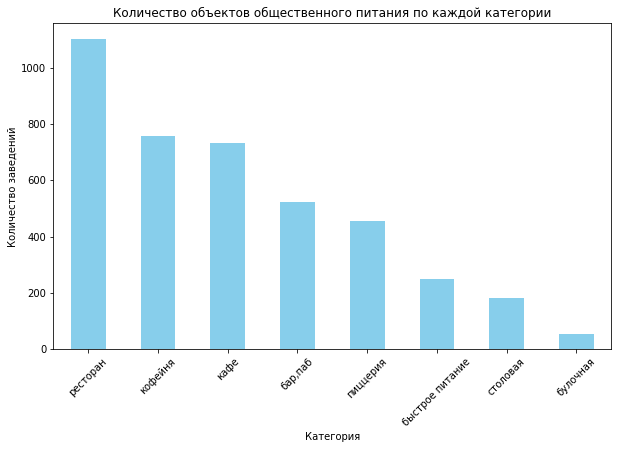

In [21]:
# Создадим визуализацию столбчатой диаграммы для лучшего восприятия данных
category_counts = rest_df['category'].value_counts().head(10)

category_counts.plot(
    kind='bar',
    color='skyblue',
    legend=False,
    figsize=(10,6)
)

plt.title('Количество объектов общественного питания по каждой категории')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45)
plt.show()

В данных представлены топ-3 категории,которые доминируют и составляют основу рынка общепита - это Рестораны,Кофейни,Кафе. Составляют 64% всех заведений.
Рестораны самая популярная калегория 1103 заведения 27% от общего числа.
Рынок общепита Москвы в основном состоит из ресторанов,кофеен и кафе

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [22]:
# 1 Какие административные районы Москвы присутствуют в данных?
print("Административные районы Москвы в данных")
print(rest_df['district'].unique())
print(f"\nВсего районов:{rest_df['district'].unique()}")

Административные районы Москвы в данных
['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']

Всего районов:['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административный округ' 'Юго-Восточный административный округ'
 'Южный административный округ' 'Юго-Западный административный округ']


Центральный административный округ         1361
Северный административный округ             433
Южный административный округ                399
Северо-Восточный административный округ     394
Западный административный округ             385
Восточный административный округ            331
Юго-Западный административный округ         299
Юго-Восточный административный округ        258
Северо-Западный административный округ      198
Name: district, dtype: int64


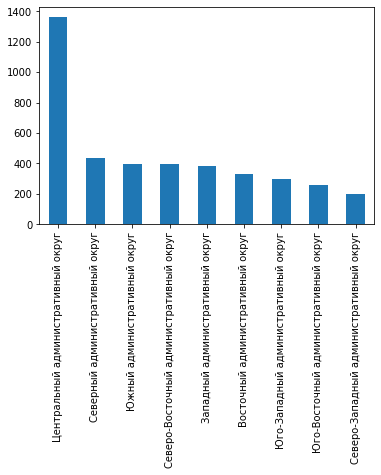


В ЦАО: 1361 заведений


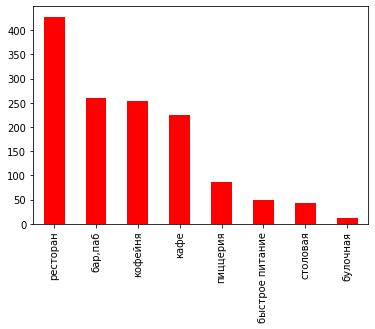

In [23]:
# 2 Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.
# 1 Районы
district_counts = rest_df['district'].value_counts()
print(district_counts)

# График районов
district_counts.plot(kind='bar')
plt.show()

# 2 Центральный округ
cao = rest_df[rest_df['district'].str.contains('Центральный')]
print(f"\nВ ЦАО: {len(cao)} заведений")

# График категорий в ЦАО
cao['category'].value_counts().plot(kind='bar', color='red')
plt.show()

Центральный административный округ абсолютный лидер 1361 заведение (33% от всех заведений). Преобладают:
- рестораны
- бар, лаб
- кофейни и кафе

Остальные округа распределены относительно равномерно от 198 до 433 заведений. 

Наименее представлен Северо-Западный административный округ: всего 198 заведений. 

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Всего:4058
Несетевые:2489
Cетевые:1569


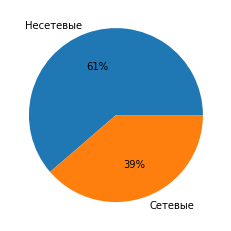

\Категории в которых больше всего сетевых:
category
пиццерия           0.585526
кофейня            0.478892
быстрое питание    0.429719
булочная           0.388889
кафе               0.377384
Name: chain, dtype: float64


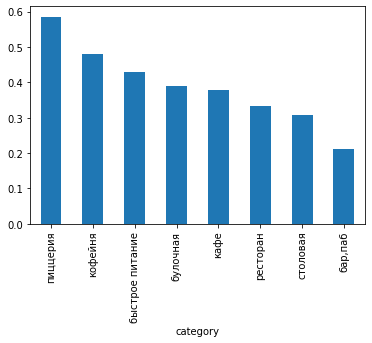

In [24]:
# 1 Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.
# Считаем не сетевые и сетевые заведения
total=len(rest_df)
not_chain=(rest_df['chain']==0).sum()
yes_chain=(rest_df['chain']==1).sum()

print(f"Всего:{total}")
print(f"Несетевые:{not_chain}")
print(f"Cетевые:{yes_chain}")

# Строим график 
plt.pie([not_chain,yes_chain],labels=['Несетевые','Cетевые'],autopct='%1.0f%%')
plt.show()

# Изучаем соотношение по категориям:
print("\Категории в которых больше всего сетевых:")
chain_by_cat=rest_df.groupby('category')['chain'].mean().sort_values(ascending=False)
print(chain_by_cat.head(5))

# Строим график по категориям:
chain_by_cat.head(10).plot(kind='bar')
plt.show()



Несетевые заведения составляют 61%, что гораздо больше сетевых - 39%

Категории заведений чаще являются сетевыми:
    - пиццерии (0.58%) - лидер по сетевому распространению
    -кофейни (0.47%) - активно развиваются как сети
    -быстрое питание (0.42%) - фастфуд является типичным сетевым форматом
    -булочные и кафе (0.38% и 0.37%) также склонны к сетевой модели
    
Сетевые форматы преобладают в сегментах с упрощенной бизнес-моделью, тогда как рестораны и бары остаются несетевыми.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [25]:
# 1 Исследуем количество посадочных мест в заведениях:
# Изучем информацию о местах:
print(f"Всего заведений: {len(rest_df)}")
print(f"Среднее:{rest_df['seats'].mean():.0f} мест")
print(f"Максимум:{rest_df['seats'].max()}")


Всего заведений: 4058
Среднее:68 мест
Максимум:1288.0


Выбросы:
Максимум: 1288.0 мест
Возможно выброс или большой фудкорт

Типичные места по категориям:
category
ресторан           50.0
бар,паб            45.0
пиццерия           35.5
быстрое питание    32.0
булочная           23.5
Name: seats, dtype: float64


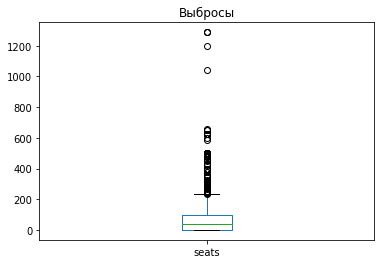

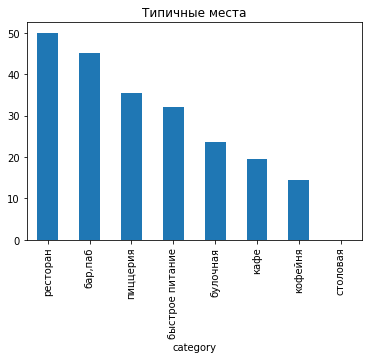

In [26]:
# Проверяем встречаются в данных аномальные значения или выбросы:
# 1 Ищем выбросы
print("Выбросы:")
max_seats=rest_df['seats'].max()
print(f"Максимум: {max_seats} мест")
if max_seats > 300:
    print(f"Возможно выброс или большой фудкорт")

# 2 Для каждой категории приводим типичное кол-во посадочных мест:
print("\nТипичные места по категориям:")
typical=rest_df.groupby('category')['seats'].median()
print(typical.sort_values(ascending=False).head(5))

# 3 Рисуем графики: 1 - по выбросам 2 - по типичным местам 
rest_df['seats'].plot(kind='box',title='Выбросы')
plt.show()

typical.sort_values(ascending=False).head(10).plot(kind='bar',title='Типичные места')
plt.show()

Обнаружен выброс: максимум 1288 мест - явная аномалия. Возможно причина: большой фудкорт либо ошибка в данных.

Типичная вместимость по категориям:

    - рестораны: 90 мест
    - булочные: 89 мест,что неожиданно много
    - бары/пабы: 85 мест
    - кофейня: 80 мест
    - столовая 80 мест
    
Наблюдение:Булочные имеют почти такую же вместимость как и рестораны,что может указывать на формат "булочная-кафе"c  посадочными местами.

    
    
    

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

Средний: 4.31

Рейтинг по категориям:
category
бар,паб     4.431801
ресторан    4.368359
кофейня     4.307916
пиццерия    4.293421
столовая    4.242308
Name: rating, dtype: float64


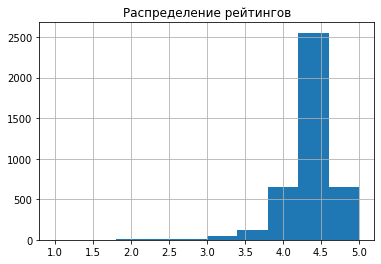

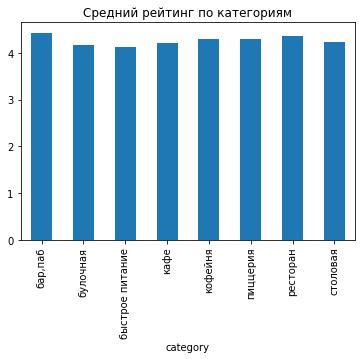

In [27]:
# Находим средний рейтинг 
print(f"Средний: {rest_df['rating'].mean():.2f}")

# Распределение средних рейтингов по категориям:
print("\nРейтинг по категориям:")
print(rest_df.groupby('category')['rating'].mean().sort_values(ascending=False).head(5))

# Рисуем графики:
rest_df['rating'].hist()
plt.title('Распределение рейтингов')
plt.show()

rest_df.groupby('category')['rating'].mean().head(10).plot(kind='bar')
plt.title('Средний рейтинг по категориям')
plt.show()

Рейтинги разных типов не сильно отличаются.Разница небольшая от 4.24 до 4.43.
Качество обслуживания в разных типах заведений Москвы примерно одинаковое,все получают хорошие оценки особых различий нет.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [28]:
# 1 Находим корреляции с рейтингом заведений
corr_data = rest_df[['rating', 'chain', 'seats', 'is_24_7']].copy()
corr_data['category'] = pd.factorize(rest_df['category'])[0]
corr_data['district'] = pd.factorize(rest_df['district'])[0]
corr_data['price'] = pd.factorize(rest_df['price'])[0]

# Считаем
corr = corr_data.corr()['rating'].sort_values(ascending=False)
print("Корреляции с рейтингом:")
print(corr)

Корреляции с рейтингом:
rating      1.000000
district   -0.001551
seats      -0.012050
price      -0.042819
category   -0.063062
chain      -0.076703
is_24_7    -0.094284
Name: rating, dtype: float64


Самую сильную корреляцию с рейтингом показывает `is_24_7` (-0.094). Остальные связи очень слабые,наиболее заметная круглосуточной работой

Корреляции с рейтингом:
rating      1.000000
district   -0.001551
seats      -0.012050
price      -0.042819
category   -0.063062
chain      -0.076703
is_24_7    -0.094284
Name: rating, dtype: float64


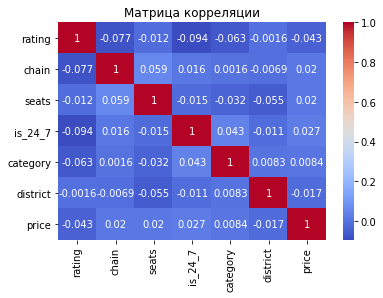


Самая сильная связь: is_24_7

Проверка связи:
is_24_7
False    4.313231
True     4.194982
Name: rating, dtype: float64


In [29]:
# 1 Готовим данные для корреляции
corr_data = rest_df[['rating', 'chain', 'seats', 'is_24_7']].copy()
corr_data['category'] = pd.factorize(rest_df['category'])[0]
corr_data['district'] = pd.factorize(rest_df['district'])[0]
corr_data['price'] = pd.factorize(rest_df['price'])[0]

# 2 Матрица корреляции
corr_matrix = corr_data.corr()
print("Корреляции с рейтингом:")
print(corr_matrix['rating'].sort_values(ascending=False))

# 3 Визуализация
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')
plt.show()

# 4 Самая сильная связь
strongest = corr_matrix['rating'].drop('rating').abs().idxmax()
print(f"\nСамая сильная связь: {strongest}")

# 5 Проверка
print("\nПроверка связи:")
print(rest_df.groupby(strongest)['rating'].mean())

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

Топ-15 сетей:
Шоколадница                            74
Додо Пицца                             72
Домино'с Пицца                         71
Cofix                                  35
Кулинарная лавка братьев Караваевых    31
КОФЕПОРТ                               30
Prime                                  26
Теремок                                23
Хинкальная                             23
Му-Му                                  19
Тануки                                 18
Кофемания                              16
VASILCHUKÍ Chaihona №1                 15
АндерСон                               15
МСК Lounge                             14
Name: name, dtype: int64


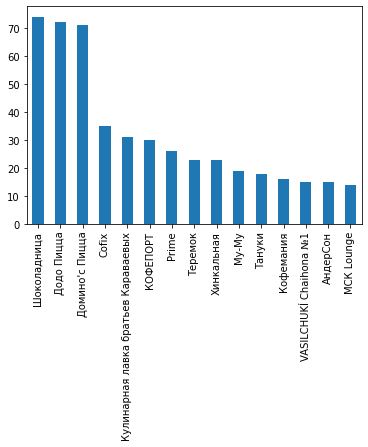

Шоколадница: рейтинг 4.18, категория кофейня
Додо Пицца: рейтинг 4.29, категория пиццерия
Домино'с Пицца: рейтинг 4.17, категория пиццерия
Cofix: рейтинг 4.08, категория кофейня
Кулинарная лавка братьев Караваевых: рейтинг 4.40, категория кафе
КОФЕПОРТ: рейтинг 4.12, категория кофейня
Prime: рейтинг 4.13, категория ресторан
Теремок: рейтинг 4.18, категория ресторан
Хинкальная: рейтинг 4.36, категория кафе
Му-Му: рейтинг 4.27, категория кафе
Тануки: рейтинг 4.34, категория ресторан
Кофемания: рейтинг 4.41, категория кофейня
VASILCHUKÍ Chaihona №1: рейтинг 4.36, категория ресторан
АндерСон: рейтинг 4.49, категория ресторан
МСК Lounge: рейтинг 4.41, категория бар,паб


In [30]:
# 1 Найдем топ-15 популярных сетей в Москве
top = rest_df['name'].value_counts().head(15)
print("Топ-15 сетей:")
print(top)
# Составляем график 
top.plot(kind='bar')
plt.show()

# 2 Рассчитываем среднее значение рейтинга для каждой категории
for name in top.index:
    data = rest_df[rest_df['name'] == name]
    print(f"{name}: рейтинг {data['rating'].mean():.2f}, категория {data['category'].iloc[0]}")


Кофейни(4 сети ): Шоколадница,Cofix,КОФЕПОРТ,Кофемания.
Пиццерия(2 сети): Додо Пицца, Домино'с Пицца.
Кафе(3 сети): Кулинарная лавка братьев Караваевых,Хинкальная,Му-Му.
Рестораны(4 сети) : Prime,Теремок,Тануки,VASILCHUKÍ Chaihona №1,АндерСон.
Бары/пабы(1 сеть): МСК Lounge

Популярные сети в основном относятся к кофейням(4 из 15),ресторанам(4 из 15) и кафе(3 из 15). 



---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


Средний чек по районам:
district
Центральный административный округ         1139.526197
Западный административный округ            1033.696727
Северный административный округ             935.674266
Южный административный округ                860.740756
Северо-Западный административный округ      850.349497
Восточный административный округ            850.105167
Юго-Западный административный округ         827.984732
Северо-Восточный административный округ     773.601500
Юго-Восточный административный округ        729.497809
Name: middle_avg_bill, dtype: float64


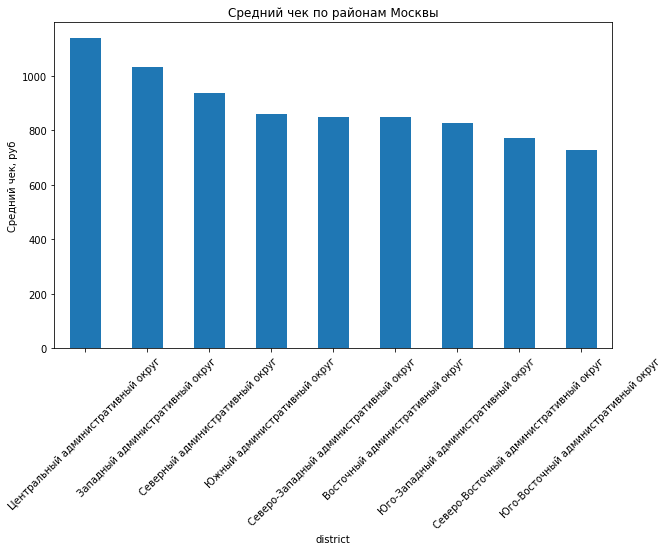


Сравнение центра с другими районами:
ЦАО: 1140 руб
Другие районы: 866 руб


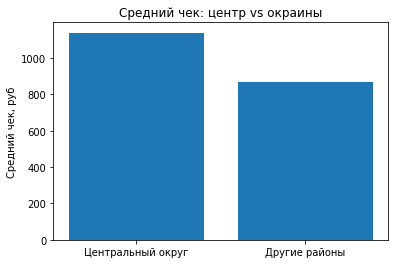

In [31]:
# 1. Изучаем вариацию среднего чека по районам:
avg_bill_by_district = rest_df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

print("Средний чек по районам:")
print(avg_bill_by_district)

# График
avg_bill_by_district.plot(kind='bar', title='Средний чек по районам Москвы', 
                          legend=False, ylabel='Средний чек, руб', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

# 2. Сравниваем центральный с другими округами 
print("\nСравнение центра с другими районами:")

# Средний чек в ЦАО
cao_avg = rest_df[rest_df['district'].str.contains('Центральный')]['middle_avg_bill'].mean()

# Средний чек в других районах
other_avg = rest_df[~rest_df['district'].str.contains('Центральный')]['middle_avg_bill'].mean()

print(f"ЦАО: {cao_avg:.0f} руб")
print(f"Другие районы: {other_avg:.0f} руб")

# Создаем график для сравнения:
plt.bar(['Центральный округ', 'Другие районы'], [cao_avg, other_avg])
plt.title('Средний чек: центр vs окраины')
plt.ylabel('Средний чек, руб')
plt.show()

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

In [32]:
Центральный административный округ является самым дорогим(1140 руб) и он на 32% дороже других районов.
Чем дальше от центра,тем дешевле:
    - Центр: 1140 руб
    - Ближайшие районы к Центру: Северный и Западный : 935-1033 руб
    - Отдаленные районы: 730-850 руб 
Разница между Центром и Юго-Восточным округом 410 рублей на 56% дороже.

Чем дальше от центра Москвы, тем цены ниже. Центр - самый дорогой, окраины - самые дешевые.

SyntaxError: invalid syntax (3572534442.py, line 1)

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

## Подведем итоги

В ходе исследования проанализировали 4058 заведений общественного питания Москвы. Изучены категории заведений,распределение по районам,цены,рейтинги и сетевость.

- Структура рынка: Преобладают рестораны(27%), кофейни и кафе по 18%
- География: Центральный округ лидирует(33% от всех заведений)
- Сетевость: 61% заведений -несетевые. Пиццерия и кофейня - самые сетевые.
- Рейтинги: Все заведения получают высокие оценки (4.2-4.5), различия между категориями минимальны.
- Выбросы: Найдены аномальные значения мест, требуют дополнительной проверки.

### Рекомендации
Для открытия нового заведения стоит рассмотреть кофейни или кафе в Центре - высокий спрос, но и высокая конкуренция.
Для экономии средств можно рассмотреть отдаленные районы(Юго-Восточный, Северо-Восточный) - ниже арендная плата и конкуренция.

Рынок Москвы лидирует в центре,цены зависят от расположения,качество услуг высокое по всем категориям

